In [7]:
import pandas as pd
import matplotlib.pyplot as plt


In [36]:
llms = ["gpt-4o", "gpt-4o-mini", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct", "qwq_32b"]
llm_names = ["GPT-4o", "GPT-4o-mini", "Llama3.1-8B", "Llama3.1-70B", "QwQ-32B"]
data_folder = "data/"
tasks = ["taxonomy", "activity", "programs"]
dataset_names = ["PAGED", "WordNet", "Clevr"]

In [37]:
runtime_results = {}

for task in tasks:
    folder = f"{data_folder}{task}"
    task_results = []
    for llm in llms:
        df = pd.read_csv(f"{folder}/{llm}_runtime_abscon_10.csv")
        df["embedding_runtime_total"] = df["embedding_runtime"].apply(lambda x: sum(eval(x)))
        df["graph_matching_runtime_total"] = df["graph_matching_runtime"].apply(lambda x: sum(eval(x)))
        df["total_runtime"] = df["embedding_runtime_total"] + df["graph_matching_runtime_total"] + df["problem_build_runtimes"] + df["problem_solve_runtimes"]
        task_results.append(df)
    runtime_results[task] = task_results    

In [38]:
runtime_results.keys()

dict_keys(['taxonomy', 'activity', 'programs'])

In [51]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Publication style setup ---
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

MEDIAN_COLOR = "#D94F3B"
EDGE_COLOR = "#333333"
y_margins = [0.05, 0.08, 0.4]

for i, (task, task_data) in enumerate(runtime_results.items()):
    data = [df["total_runtime"].values for df in task_data]

    fig, ax = plt.subplots(figsize=(3.5, 2.8))

    bp = ax.boxplot(
        data,
        tick_labels=llm_names,
        showfliers=False,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color=MEDIAN_COLOR, linewidth=1.5),
        whiskerprops=dict(color=EDGE_COLOR, linewidth=0.8),
        capprops=dict(color=EDGE_COLOR, linewidth=0.8),
        boxprops=dict(facecolor="white", edgecolor=EDGE_COLOR,
                      linewidth=0.8),
    )
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * y_margins[i])

    ax.set_ylabel("Total Runtime (s)")
    # ax.set_xlabel("LLM")
    ax.set_title(f"{dataset_names[i]}", pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=45, labelsize=8.5)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)

    # fig.tight_layout()
    fig.savefig(f"{task}_total_runtime_boxplot.pdf")
    plt.close(fig)
    # plt.show()


In [ ]:
import numpy as np

# --- Palette (colorblind-friendly, muted for print) ---
COMPONENT_COLORS = ["#4878A8", "#E07B54", "#5DA57D", "#B07AA8"]
EDGE_COLOR = "#333333"

for i, (task, task_data) in enumerate(runtime_results.items()):
    components = {
        "Embedding":      [task_data[j]["embedding_runtime_total"].mean() for j in range(len(llm_names))],
        "Graph Matching":  [task_data[j]["graph_matching_runtime_total"].mean() for j in range(len(llm_names))],
        "Problem Build":   [task_data[j]["problem_build_runtimes"].mean() for j in range(len(llm_names))],
        "Problem Solve":   [task_data[j]["problem_solve_runtimes"].mean() for j in range(len(llm_names))],
    }

    fig, ax = plt.subplots(figsize=(3.5, 2.8))
    bottom = np.zeros(len(llm_names))

    for (label, times), color in zip(components.items(), COMPONENT_COLORS):
        vals = np.array(times)
        ax.bar(
            llm_names, vals, width=0.5,
            label=label, bottom=bottom,
            color=color, edgecolor=EDGE_COLOR, linewidth=0.4,
        )
        bottom += vals

    ax.set_ylabel("Average Time (s)")
    ax.set_title(f"{dataset_names[i]}", pad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="x", rotation=45, labelsize=8.5)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    ax.set_axisbelow(True)

    # Replace the legend line with:
    if i == len(runtime_results) - 1:
        ax.legend(fontsize=7, frameon=False, loc="upper right")

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.05)

    fig.savefig(f"{task}_runtime_breakdown_stacked_bar.pdf", bbox_inches="tight")
    plt.close(fig)

## Check the relation between entropy and runtime

In [7]:
import pickle
import numpy as np


In [49]:
task_partial_models = {}

for task in tasks:
    folder = f"{data_folder}{task}"
    task_partial_models[task] = []
    for llm in llms:
        filename = f"{folder}/{llm}_partial_models_10.pkl"
        with open(filename, "rb") as f:
            partial_models = pickle.load(f)
        task_partial_models[task].append(partial_models)

num_candidates = 10

# convert the partial model weight to probability
for task, task_partiam_models in task_partial_models.items():
    for partial_models in task_partiam_models:
        for partial_model in partial_models:
            for node, data in partial_model.nodes(data=True):
                if "weight" in data:
                    data["weight"] = data["weight"] / num_candidates
            for u, v, data in partial_model.edges(data=True):
                if "weight" in data:
                    data["weight"] = data["weight"] / num_candidates
        

In [50]:
def calculate_entropy(partial_models):
    entropies = []
    for partial_model in partial_models:
        node_weights = np.array([data["weight"] for _, data in partial_model.nodes(data=True) if "weight" in data])
        edge_weights = np.array([data["weight"] for _, _, data in partial_model.edges(data=True) if "weight" in data])
        weights = np.concatenate((node_weights, edge_weights))

        if len(weights) > 0:
            # Each weight corresponds to a probability of a binary event
            # Adding a small constant to avoid log(0)
            # value = (-np.sum(weights * np.log2(weights + 1e-10)) - np.sum((1 - weights) * np.log2(1 - weights + 1e-10)))
            
            # calculate the number of non-1 weights
            value = (weights != 1).sum()
            entropies.append(value)
    return entropies

In [51]:
task_entropies = {}

for task, task_partial_models in task_partial_models.items():
    task_entropies[task] = []
    for partial_models in task_partial_models:
        entropies = calculate_entropy(partial_models)
        task_entropies[task].append(entropies)

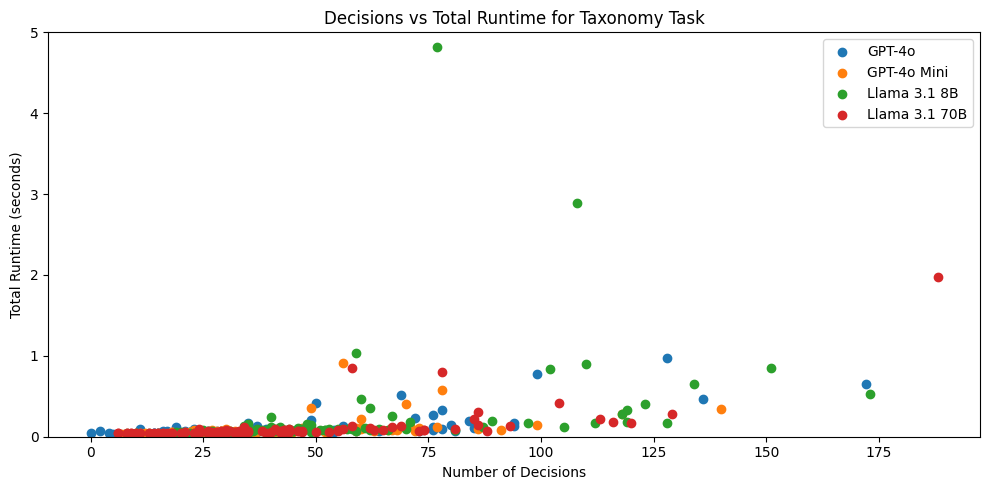

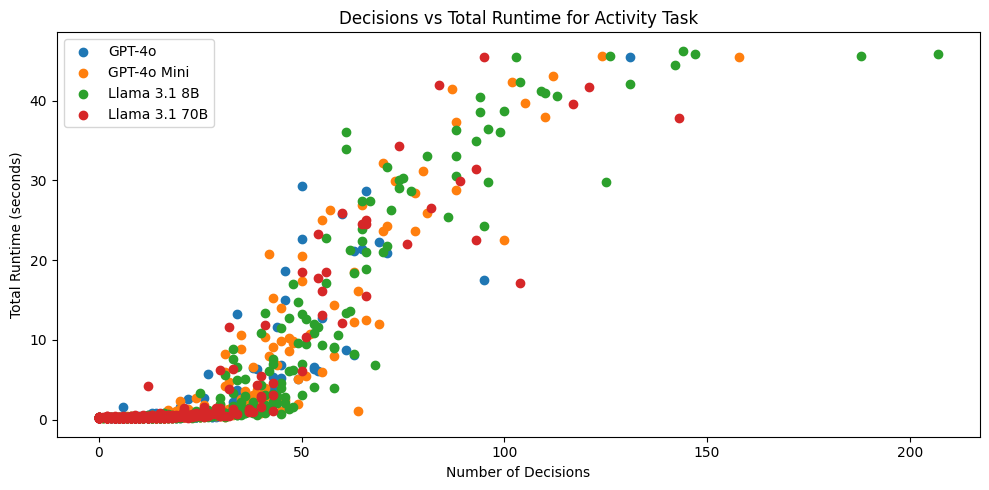

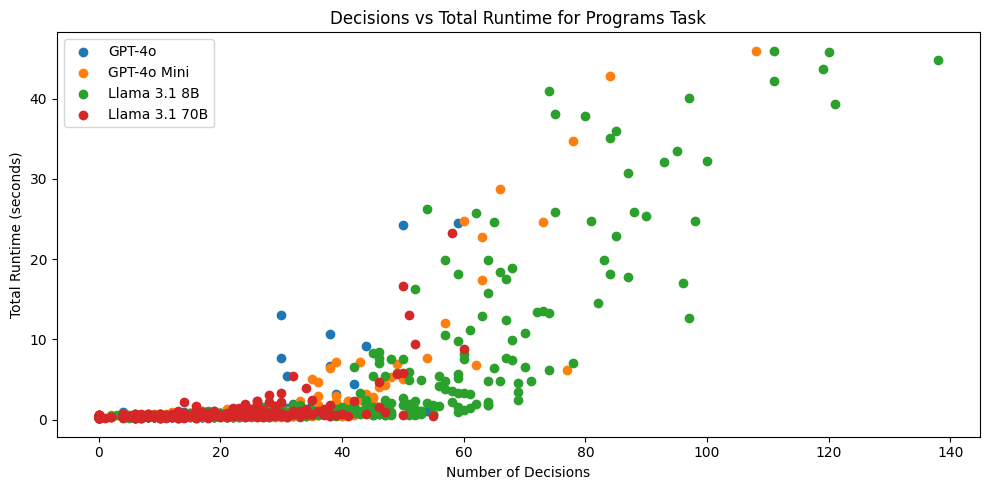

In [55]:
# Plotting the scatter plot for entropy and total runtime on the same graph for each task with different colors for each LLM
for task, task_data in runtime_results.items():
    plt.figure(figsize=(10, 5))
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        entropies = task_entropies[task][i]
        total_runtime = df["total_runtime"].values
        plt.scatter(entropies, total_runtime, label=llm)
    
    plt.title(f"Decisions vs Total Runtime for {task.capitalize()} Task")
    plt.xlabel("Number of Decisions")
    plt.ylabel("Total Runtime (seconds)")
    plt.legend()

    if task == "taxonomy":
        plt.ylim(0, 5)

    plt.tight_layout()
    plt.savefig(f"{task}_entropy_vs_runtime.png")
    plt.show()

In [53]:
# Check the correlation between entropy and runtime for each task
from scipy.stats import pearsonr, spearmanr


In [54]:
# Check the correlation between entropy and runtime for each task
for task, task_data in runtime_results.items():
    total_runtimes = []
    entropies = []
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        entropies.extend(task_entropies[task][i])
        total_runtimes.extend(df["total_runtime"].values)
    
    pearson_corr, pearson_p = pearsonr(entropies, total_runtimes)
    spearman_corr, spearman_p = spearmanr(entropies, total_runtimes)
    print(f"Task: {task.capitalize()}")
    print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
    print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

Task: Taxonomy
Pearson correlation: 0.2453 (p-value: 0.0000)
Spearman correlation: 0.8250 (p-value: 0.0000)
Task: Activity
Pearson correlation: 0.8800 (p-value: 0.0000)
Spearman correlation: 0.8762 (p-value: 0.0000)
Task: Programs
Pearson correlation: 0.7042 (p-value: 0.0000)
Spearman correlation: 0.7642 (p-value: 0.0000)


## Graph Matching Runtime v.s. Number of candidates

In [97]:
task_graph_matching_time = {}
for task, task_data in runtime_results.items():
    task_graph_matching_time[task] = []
    for i, (llm, df) in enumerate(zip(llm_names, task_data)):
        embedding_runtimes = df["graph_matching_runtime"].apply(lambda x: eval(x)).tolist()
        task_graph_matching_time[task].append(embedding_runtimes)

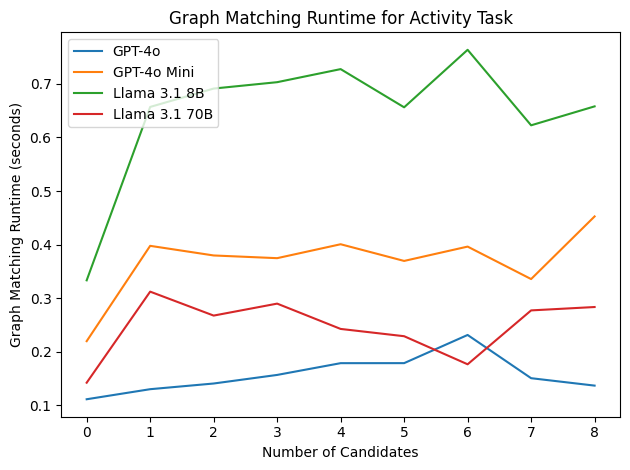

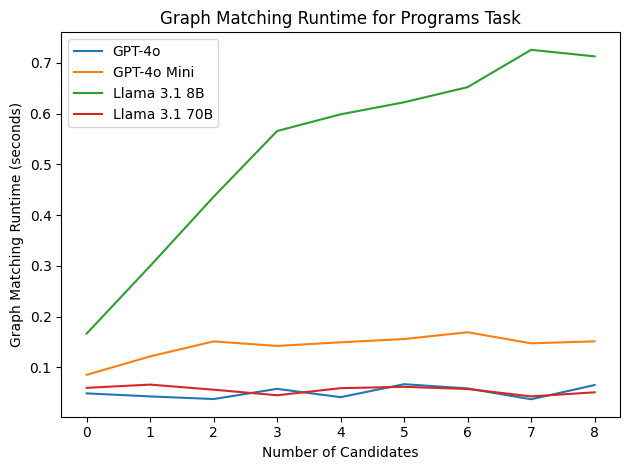

In [99]:
# Plotting the runtime distribution for each LLM and each task
for task, task_data in task_graph_matching_time.items():
    if task == "taxonomy":
        continue
    for i, (llm, runtimes) in enumerate(zip(llm_names, task_data)):
        x_range = range(9)
        y_data = []
        for i in x_range:
            candidate_runtimes = [r[i] for r in runtimes if len(r) > i]
            y_data.append(np.mean(candidate_runtimes))
        plt.plot(x_range, y_data, label=llm)
    plt.title(f"Graph Matching Runtime for {task.capitalize()} Task")
    plt.xlabel("Number of Candidates")
    plt.ylabel("Graph Matching Runtime (seconds)")
    plt.xticks(x_range, [str(i) for i in x_range])
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{task}_graph_matching_runtime.png")
    plt.show()